In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = "D:/FY_Project/Ai-CDD/data/raw/segmentation_sample/images"
MASK_DIR  = "D:/FY_Project/Ai-CDD/data/raw/segmentation_sample/masks"


IMG_SIZE = 256



In [2]:
def load_image_mask(image_path, mask_path, img_size=256):
    # Load grayscale image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize
    image = cv2.resize(image, (img_size, img_size))
    mask  = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)

    # Normalize image
    image = image.astype(np.float32) / 255.0

    # Binarize mask
    mask = (mask > 0).astype(np.uint8)

    # Add channel dimension
    image = np.expand_dims(image, axis=-1)
    mask  = np.expand_dims(mask, axis=-1)

    return image, mask


In [3]:
def load_dataset(image_dir, mask_dir):
    images = []
    masks = []

    image_files = sorted(os.listdir(image_dir))

    for img_file in image_files:
        img_path = os.path.join(image_dir, img_file)
        mask_file = img_file.replace(".png", "_mask.png")
        mask_path = os.path.join(mask_dir, mask_file)

        if not os.path.exists(mask_path):
            continue  # safety check

        img, mask = load_image_mask(img_path, mask_path)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)


In [6]:
X, Y = load_dataset(IMAGE_DIR, MASK_DIR)

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)
print("Image dtype:", X.dtype)
print("Mask unique values:", np.unique(Y))


Images shape: (50, 256, 256, 1)
Masks shape: (50, 256, 256, 1)
Image dtype: float32
Mask unique values: [0 1]


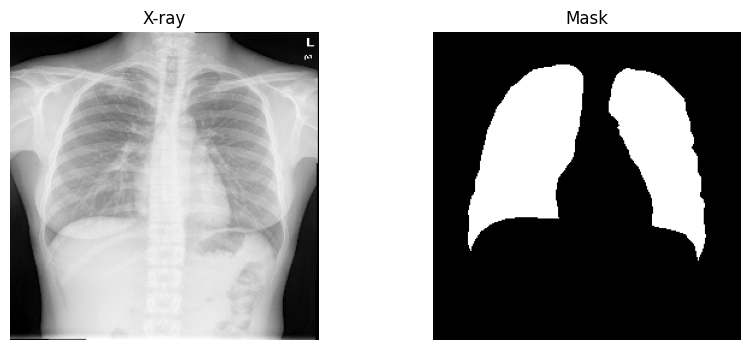

In [7]:
idx = np.random.randint(0, len(X))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(X[idx].squeeze(), cmap="gray")
plt.title("X-ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Y[idx].squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()
